##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Databazen🤓]

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.000100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]

---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load & Merge dataset(s)**

Eigenlijk is de rede dat wij hier een left join gebruiken hetzelfde als in de vorige iteratie. iter3 dataset bevat 2 nieuwe kolommen met ship_id, aangezien iter2_cleaned csv ons opgeschoonde bestaand is van iteratie 2 is deze de left en de iter3 de right. Zodat de hele dataset van iteratie 2 blijft met de kolommen van iteratie 3 erbij met overeenkomende ship_id's

Tuurlijk kan right join ook maar dan zou je de bestanden om moeten draaien dus iter 2 csv wordt df2 en iter3 csv wordt df1 want anders ben je alle data van iteratie 2 kwijt.

En we willen alle ship_id's van iteratie 2 houden dus ook geen inner join om onnodig dataverlies te voorkomen.

In [2]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID
df1 = pd.read_csv("Data/ship_inspections_iter2_cleaned.csv")
df2 = pd.read_csv("Data/ship_performance_logs_iter3.csv")

merged_df = pd.merge(df1, df2, on="Ship_ID", how="left")

merged_df.to_csv("Data/ship_inspections_iter3_merged.csv", index=False)

df = pd.read_csv("Data/ship_inspections_iter3_merged.csv")

---

## 1. Business Understanding

**Situation description**

Nebula Brokerage is op dit moment de marktleider, maar er is veel druk van aandeelhouders en de concurrenten nemen toe. De eerdere modellen uit Iteratie 1 en 2 waren een goede basis, maar zijn niet genoeg voor een miljoenenbedrijf als Nebula Brokerage. Het huidige model verliest credits op high- performance schepen die te goedkoop worden aangeboden en versleten schepen worden te weinig gekocht omdat ze te duur zijn. Ook onze handmatige regels voor de conditie van schepen zijn gebaseerd op aannames van mensen,deze regels missen vaak subtiele patronen of risico's die verborgen zijn, zoals juridische geschiedenis uit het Imperial Registry. Een gestolen schip kan er van buiten goed uitzien, maar is een groot juridisch risico.

**Business objective(s)**

Het doel is om de winstmarges hoger te maken en de operationele risico's te verkleinen door over te stappen naar algoritmes. Als de prijsbepaling nog nauwkeuriger wordt gaat de doorloop van voorraad sneller en krijgen we hogere marges op de goede schepen. De conditie van de schepen voorspellen, voorkomt Nebula Brokerage rechtszaken en schade aan hun reputatie door het verkopen van illegale schepen.

**Data mining goal(s)**

Regressie (Linear Regression). De Galactic_Credits waarde voorspellen door variabelen zoals Lightyears_Traveled toe te voegen, kan het  model leren hoe de prijs daalt als een schip meer heeft gevlogen. 

Classificatie (Decision Tree). We gaan de categorie Hull_Intergrity voorspellen, met de decision tree gaan we verbanden vinden tussen dingen zoals de technische staat, de leeftijd en de juridische data uit het Imperial Registry die we met handmatige regels over het hoofd kunnen zien.

**Success criteria**

-De foutmarges (MAE en RMSE) lager maken dan die van het model uit Iteratie 1.

-De decision tree een hogere accuracy geven dan het model van Iteratie 2. Minder onveilige schepen die als veilig worden gemarkeerd.

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

De Describe laat al gelijk een aantal dingen opvallen aan Lighyears travelled. Als eerst zie je dat min en max heel ver van het gemiddelde afzitten er zitten dus zeker uitschieters in. Verder als je naar de count van ship_ID kijkt en naar Lightyears zie je ook al gelijk dat er een aantal missen. Dit betekend dat we te maken hebben met data die niet heel goed te vertouwen is. Ook is het gemiddelde groter dan de mediaan en dus zal het rechts scheef zijn of positief.

In [3]:
# CODE CELL: Show basic statistics and information for the final merged dataset
df.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.603060e+05,360306.000000,360306.000000,360306.000000,353811.000000
mean,7.311483e+09,19232.728903,7511.284225,70.657830,104.839485
std,4.381778e+06,14286.210766,9.015043,42.940156,88.941682
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7950.000000,7508.000000,40.000000,30.622182
50%,7.312599e+09,15990.000000,7513.000000,60.000000,85.496024
75%,7.315244e+09,27990.000000,7517.000000,80.000000,157.572045
max,7.317101e+09,99999.000000,7522.000000,360.000000,1559.606111


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

Wij hebben gekozen om spearman te gebruiken voor correlatie. Dit hebben wij gedaan omdat je hierboven kan zien dat Galactic credits, Reactor power en Lightyears traveled rechts scheef zijn. Voor Pearson moeten ze normaal verdeeld zijn. Verder zijn er grote uitschieters bij Lighyears traveled en ook wel bij Galactic Credits. Reactor power heeft ook redelijk grote uitschieter. Hierdoor leek het ons het beste om spearman te gebruiken. De heatmap laat zien dat er een aantal verbanden zijn. Redelijk sterk positieve correlatie bij Galactic credits en Model cycle. Zwak positief bij Galactic credits en Reactor power. Sterk negatief bij Galactic credits en Lightyears traveled en sterk negatief bij Lightyears traveled en Model Cycle. Hieronder gaan wij deze correlaties nog verder visualiseren om een beter beeld hierbij te krijgen.

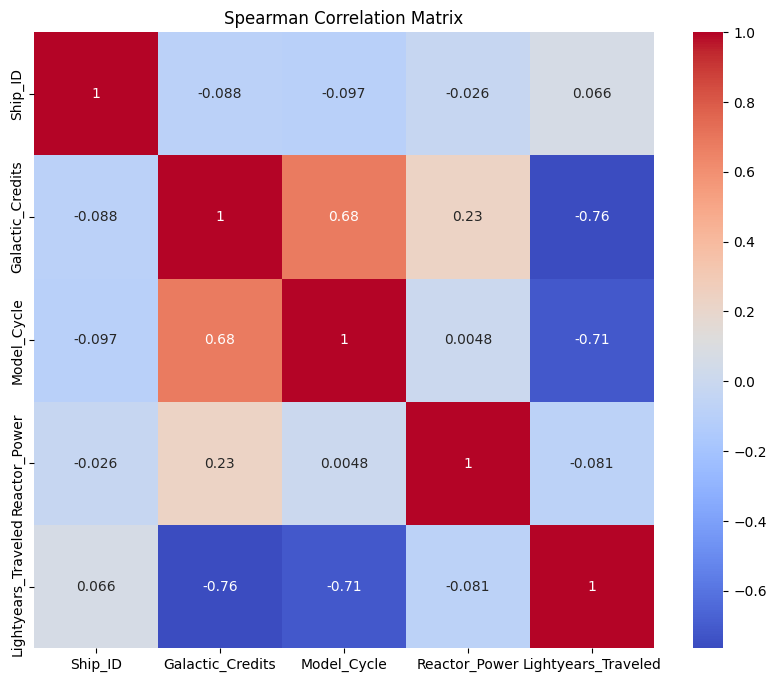

In [4]:
nummer_df = df.select_dtypes(include='number')
corr_matrix = nummer_df.corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Matrix")
plt.show()

Deze scatterplot is gemaakt om te kijken welke prijs van de schepen bij welke lightyears travelled hoort. Er is gekozen voor een scatterplot omdat we met 2 numerieke waardes werken. Dit leek ons het beste omdat je anders bijvoorbeeld bij een plot bar je veel te veel verschillende opties krijgt. Je zou kunnen zeggen dat schepen die niet veel lightyears travelled hebben elke prijs kunnen hebben. Hoe meer lightyears travelled hoe goedkoper de schepen worden. Dit is niet 100% voor elk schip zo, maar het is wel te zien dat er iets gaande is. Waarschijnlijk is er een sterke negatieve correlatie want hoe hoger de prijs hoe lager de lightyears travelled. Dit is ook logisch, want hoe meer je met een schip vliegt hoe minder het waard wordt.

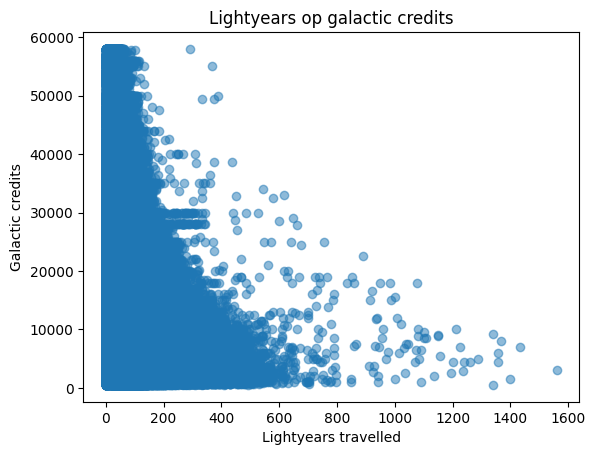

In [5]:
# CODE CELL: Generate visualizations for the new features
plt.scatter(df['Lightyears_Traveled'], df['Galactic_Credits'], alpha=0.5)
plt.title('Lightyears op galactic credits')
plt.xlabel('Lightyears travelled')
plt.ylabel('Galactic credits')
plt.show()

Deze scatterplot laat niet echt een negatieve correlatie zien. Dit komt waarschijnlijk omdat model cycle een kleine range heeft en Lightyears traveled juist een grote range heeft. Verder hebben wij niet echt een manier gevonden om dit beter te laten zien. Je zou in dit geval van de scatterplot zelfs kunnen zeggen dat er een positief verband is.

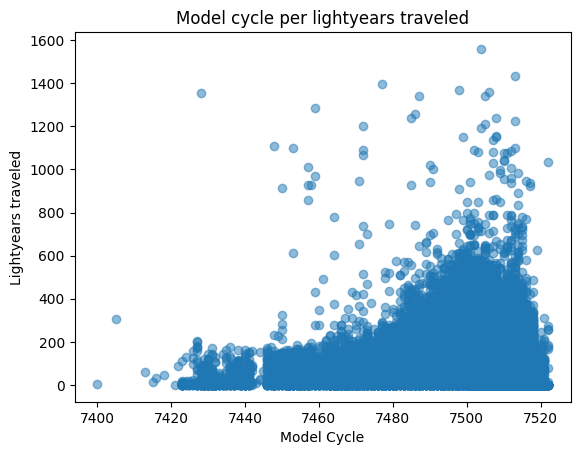

In [6]:
plt.scatter(df['Model_Cycle'], df['Lightyears_Traveled'], alpha=0.5)
plt.title('Model cycle per lightyears traveled')
plt.xlabel('Model Cycle')
plt.ylabel('Lightyears traveled')
plt.show()

Zoals je ziet is imperial certified de klas met de meeste schepen. De minste zijn unknown. Scrap en stolen zijn ongeveer evenveel als elkaar. Wij hebben gekozen om deze grafiek te gebruiken een bar plot omdat deze het beste visueele beeld geeft per categorie.

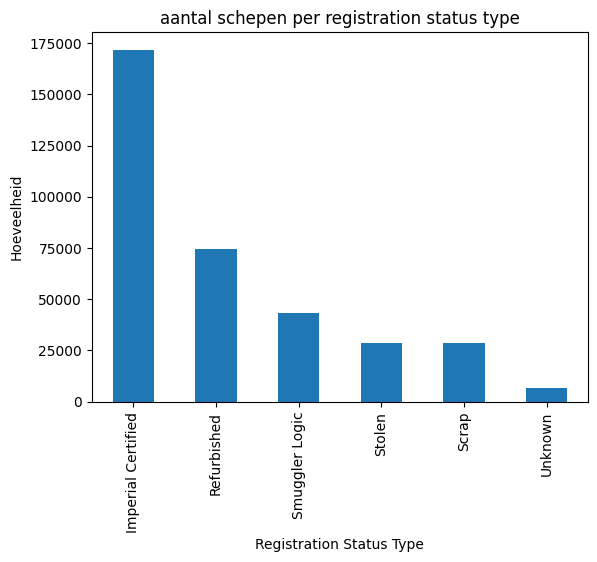

In [7]:
df['Registration_Status'].value_counts().plot.bar()
plt.xlabel("Registration Status Type")
plt.ylabel("Hoeveelheid")
plt.title("aantal schepen per registration status type")
plt.show()

De boxplot laat zien hoeveel lightyears traveled hoort bij welke Hull Integrity. Je kan zien dat Pristine het laagste is en daarna operational komt. Daarna komt cricital. Het bouwt soort van op naar boven. Er is gekozen voor boxplots omdat dit ons het handigste leek. Omdat je met numerieke waarde werkt waar er erg veel van zijn is het moeilijk om dit precies te laten zien zonder waardes te verliezen. We hebben gekozen voor stapjes van 200 omdat dit niet te veel waardes verliest. Het laat alles wel duidelijk genoeg zien en we missen geen belangrijke waardes.

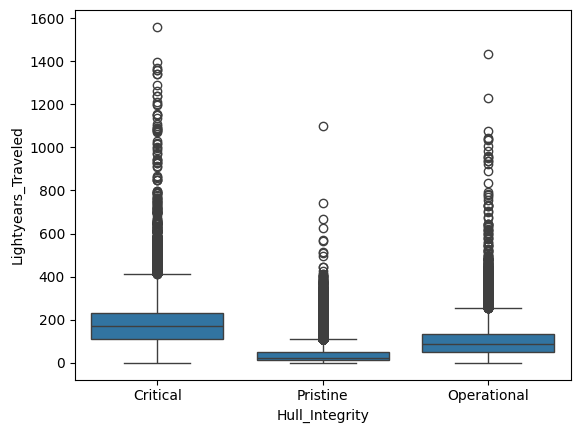

In [8]:
sns.boxplot(x='Hull_Integrity', y='Lightyears_Traveled', data=df)

plt.show()

Je ziet bij dit figuur al snel dat er correlatie is tussen stolen en critical. Dit komt omdat er ongeveer 25000 critical schepen stolen zijn. Bij pristine en opperational is het bij elkaar opgeteld ongeveer 3000. Verder zien we dat Imperial Certified bij Pristine en Operational het hoogste zijn. Dit komt waarschijnlijk omdat dit de meest voorkomende waardes zijn. 

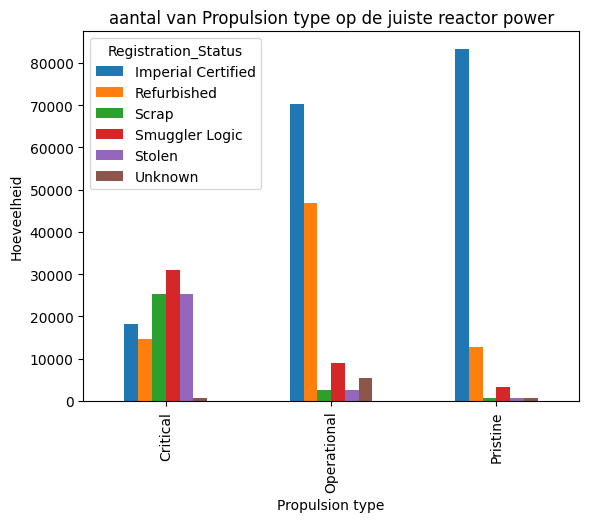

In [9]:
df.groupby('Hull_Integrity')['Registration_Status'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("aantal van Propulsion type op de juiste reactor power")
plt.show()

Er staan geen typfouten in de rij van registration status. Voor de Light years traveled zijn niet zo zeer typfouten die wij hebben gevonden. Eigenlijk alleen best rare uitschieters. Er is een 0 en een 1500.

In [10]:
df['Registration_Status'].value_counts()

Registration_Status
Imperial Certified    171756
Refurbished            74363
Smuggler Logic         43277
Stolen                 28818
Scrap                  28808
Unknown                 6789
Name: count, dtype: int64

**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

Aangezien we nu 2 kolommen erbij hebben met een aantal lege waardes moeten we deze op een manier weer vullen, aangezien bij sommige de registration_status al op unknown staat is het logisch om de lege waardes deze zelfde status te geven, aangezien er geen veilige manier is om die status op een andere manier in te vullen.

Voor de lightyears travelled hebben we dit zo aangepakt. Er is een negatieve correlatie tussen de staat van het schip en het aantal gereisde lightyears, vullen we ontbrekende waarden in op basis van die relatie. Schepen in slechte staat hebben vaak meer gereisd dan schepen in goede staat. Daarom vervangen we ontbrekende light years travelled bij schepen met een critical hull integrity door het gemiddelde aantal lightyears van alle schepen met dezelfde hull-status, en daarbij ook op diezelfde manier voor de operational en pristine integrity. Aangezien het niet eerlijk is om de gemiddelde te pakken van de gehele kolom aangezien critical schepen deze gereisde tijd verhogen voor de pristine schepen met lege waardes.

En de laatste command geeft weer dat er geen lege waardes meer zijn in het csv bestand

In [11]:
df_clean = df

df_clean['Registration_Status'] = df_clean['Registration_Status'].fillna('Unknown')

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Pristine') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Pristine',
    'Lightyears_Traveled'
].mean()

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Operational') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Operational',
    'Lightyears_Traveled'
].mean()

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Critical') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Critical',
    'Lightyears_Traveled'
].mean()

df_clean.to_csv("Data/ship_inspections_iter3_cleaned.csv", index=False)

df.isna().sum()

Ship_ID                0
Galactic_Credits       0
Model_Cycle            0
Ship_Manufacturer      0
Sector                 0
Hull_Integrity         0
Reactor_Power          0
Propulsion_Type        0
Ship_Class             0
Lightyears_Traveled    0
Registration_Status    0
dtype: int64

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

**One-hot encoding**
Om deze categorie kolommen om te zetten in een format wat een model kan gebruiken moeten we de categorieen opslitsen in getallen dus elke soort kolom, dus bijvoorbeeld bij hull integrity pristine, operational en critical. Dit gebeurd via one-hot encoding, daarvan maak je bij elke categorie een kolom waarin true or false staat (0 of 1). Zo kan een model lezen wanneer een kolom een bepaalde categorie is en daarop verder werken. Hierbij hebben we een nieuw bestand gemaakt waarin deze encoding gebruikt wordt want anders is het voor een mens heel irritant om te lezen 

**Dataset split**
Hierin hebben wij de dataset gesplitst in train en test (80/20) met als voorbeeld target Lightyears_travelled. Dit is nodig om het model eerlijk te evalueren, omdat het wordt getest op data die het nog niet eerder heeft gezien. Hierdoor voorkomen we dat het model de trainingsdata uit het hoofd leert (overfitting) en krijgen we een realistischer beeld van hoe goed het model presteert op nieuwe data. Zodat het model alle data eerlijk bekijkt zonder enige bias. De prestaties van het model werden gemeten d.m.v. MAE, RMSE en R2.

In [12]:
# Variabele voor alle categorische kolommen
categorical_cols = ['Ship_Manufacturer', 'Sector', 'Hull_Integrity',
                    'Propulsion_Type', 'Ship_Class', 'Registration_Status']

# One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# Opslaan van encoded dataset
df_encoded.to_csv("Data/ship_inspections_iter3_encoded.csv", index=False)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X = alles behalve de target
# y = target Lightyears_Traveled
X = df_encoded.drop('Lightyears_Traveled', axis=1)
y = df_encoded['Lightyears_Traveled']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model trainen
model = LinearRegression()
model.fit(X_train, y_train)

# Voorspellingen maken
y_pred = model.predict(X_test)

# Metrics berekenen
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 43.087134845998065
RMSE: 60.45002147747588
R²: 0.5309729047222906


---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [13]:
from sklearn.linear_model import LinearRegression

X_reg = df_encoded.drop(['Ship_ID', 'Galactic_Credits'], axis=1)
y_reg = df_encoded['Galactic_Credits']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

MAE: 5817.09
R2 Score: 0.6663


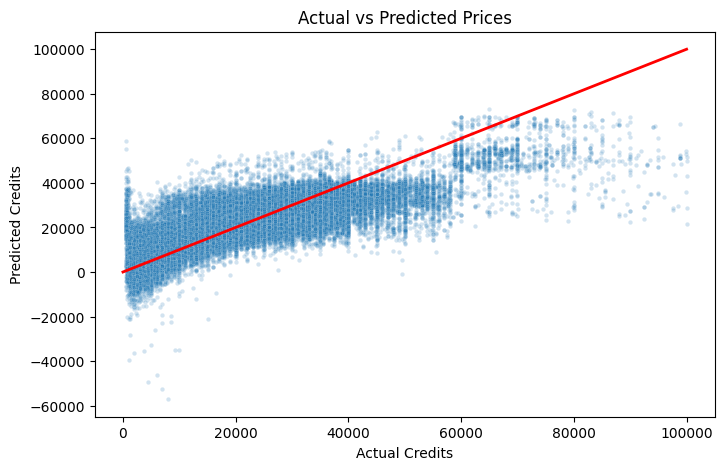

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_reg = reg_model.predict(X_test_reg)

print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.2, s=10)
plt.plot([0, 100000], [0, 100000], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Credits')
plt.ylabel('Predicted Credits')
plt.show()

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [15]:
from sklearn.tree import DecisionTreeClassifier

y_clf = df_clean['Hull_Integrity']
X_clf = df_encoded.drop(['Ship_ID', 'Galactic_Credits', 'Hull_Integrity_Pristine', 
                         'Hull_Integrity_Operational', 'Hull_Integrity_Critical'], axis=1)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = DecisionTreeClassifier(max_depth=6, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

Accuracy: 0.8597


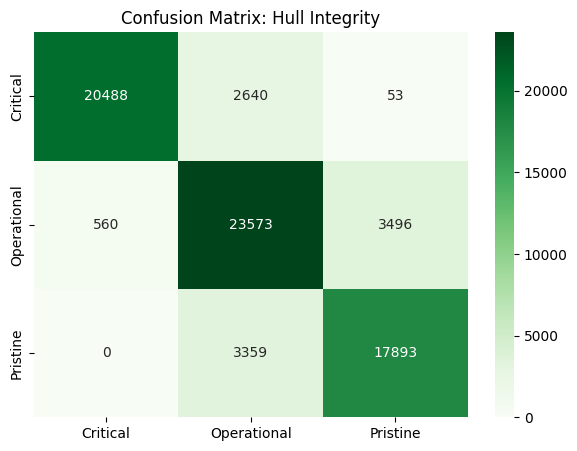

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_clf = clf_model.predict(X_test_clf)

print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")

cm = confusion_matrix(y_test_clf, y_pred_clf, labels=clf_model.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf_model.classes_, yticklabels=clf_model.classes_, cmap='Greens')
plt.title('Confusion Matrix: Hull Integrity')
plt.show()

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are the scores of this regression model better than Iteration 1? Why?*
De score van iteratie 3 zijn beter dan die van iteratie 1. Dit komt omdat die van Iteratie 3 niet alleen de mediaan kan voorspellen. Verder gebruikt het model van iteratie 3 al eerder bekende data en leert daarvan. Die van iteratie 1 doet dat niet. Hierdoor is die van iteratie 3 dus percieser.

* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*
De scores van het predicten van de Hull Integrity zijn een stuk beter we zijn van 69.41% naar 85% gegaan. Dit komt vooral omdat die van Iteratie 2 handgemaakte regels had. Die van deze iteratie zijn juist geleerd op oude data en toegepast op nieuwe data. Hierdoor ook het grote verschil in accuracy.
**Key findings and limitations**

De key findings Met pearson en spearman hebben wij uitgevonden dat je op deze manier makkelijk correlaties kan vinden. Het nadeel hiervan is wel direct het uitvinden wanneer je pearson gebruikt en wanneer je spearman gebruikt, gelukkig was het in dit geval vrij duidelijk dat wij spearman moesten gebruiken. Verder is het visualiseren van sommige correlaties moeilijk, zoals die van Model cycle en Lightyears traveled, aangezien het niet duidelijk is of er daadwerkelijk een bruikbaar verband bestaat tussen deze waardes. Daardoor is het moeilijk om te bepalen of dit gebruikt kan worden voor het data preparation gedeelte. Verder hebben wij de data mining goals behaald. De 2 modellen scoren beter als die van de eerdere iteraties, alleen e scatterplot van actual tegen predicted values laat zien dat de meeste voorspellingen redelijk dicht bij de voorspelde rode lijn liggen, maar dat er nog steeds spreiding aanwezig is.

*What are the final conclusions? 
De nieuwe modellen zijn een toegevoegde waarde voor Nebula Brokerage. De overstap van onberbuikgevoel en handmatige regels van het begin naar algoritmes hier bij Iteratie 3 zorgt voor een halvering van de foutmarge en prijsbepaling! Dit resulteert gelijk in hogere winst en snellere doorloop van de voorraad. De toegevoegde waarde van de nieuwe data is heel groot, Lightyears_Traveled geeft het model inzicht in de slijtage van het schip, dit geeft meer inzicht dan alleen het bouwjaar van een schip. de Registration_Status is ook handig, zo kan het model gestolen of illegale schepen vaker in Critical zetten omdat ze waarschijnlijk niet veel officiele onderhoud hebben gehad. In het einde hebben wij dus de data mining goals behaald. Nebula zou onze algoritmes kunnen gebruiken, maar ze kunnen ook profesionnals inhuren in plaats van studenten in opleiding.

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xander UijtdeHaag | Business Understanding, Modeling A en B | Ik heb verder geleerd hoe ik ruwe data omzet in goede business voorspellingen met linear regression en decision trees. het model moest niet alleen een hoge accuracy hebben maar ook uitlegbaar zijn. Ik heb gerealiseerd dat een te diepe boom leidt tot overfitting en dat een simpeler model betrouwbare patronen herkent. Ook heb ik geleerd hoe ik technische resultaten zoals de foutmarges en de Confusion matrix vertaal naar commerciele risicos en kansen. |
| Jamie Eversdijk | Correlatie hull integrity en lightyears travelled, data cleaning, one-hot endoding + train test split daarvan | Ik heb vooral geleerd hoe je die one hot encoding model toepast op categorie data kolommen, zodat deze kunnen worden gebruikt voor machine learning modellen. Dit was best te doen alleen het bestand wat er toen uitkwam vond ik zelf heel onoverzichtelijk. Dus heb ik besloten om dit encoded bestand apart te zetten zodat er nog een overzichtelijke versie bestaat van iteratie 3. Ik heb verder geleerd hoe je correlaties moet herkennen en daarbij lege kolommen moet invullen, bijvoorbeeld de keuze om het gemiddelde te pakken van light years op elke categorie Hull_Integrity, zodat nieuwe schepen niet de dupe zijn van hoge waardes door de oudere schepen en vice versa.|
| Jero den Exter | Data preperation alles gemaakt, Evaluation besproken met iedereen samen en samenvatting gemaakt. | Ik heb geleerd over spearman en pearson. Ik liep vast bij het bepalen of er spearman of pearson gebruikt moest worden, want voor mijn gevoel kon pearson bij model cycle en de rest bij spearman. Verder heb ik ook gekeken naar modeling. Modeling heb ik gevonden dat het lijkt op het model van iteratie 1 en 2. Ik liep hier niet zo zeer vast. Bij de heatmap vond ik het eerst lastig om te snappen wat het verschil is tussen negatieve en positieve correlatie. Uiteindelijk ben ik er uit gekomen, maar ik vond dit wel erg lastig.